In [ ]:
#load the data 
import pandas as pd
window_assignment = pd.read_csv('/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows/combined_gene_peak_assignments_100kb.csv')
window_assignment.head()

,gene_id,assigned_peaks
0,a1cf,"['12-6186644-6187111', '12-6190483-6191143', '..."
1,a2ml,"['15-21143884-21144162', '15-21033797-21034001..."
2,aaas,"['9-323370-323691', '9-209853-211311', '9-2304..."
3,aacs,"['5-18949828-18950713', '5-18811696-18812645',..."
4,aadac,"['15-1052335-1053001', '15-1029184-1030074', '..."


In [2]:
window_assignment[window_assignment['gene_id'] == "zgc:171695"]["assigned_peaks"].values[0]

"['7-3094014-3094231', '7-3024771-3024974', '7-2936068-2936742', '7-3098511-3099164']"

In [3]:
# count the number of peaks assigned to each gene
#make the assigned_peaks column a list of peaks instead of a string
window_assignment["assigned_peaks"] = window_assignment["assigned_peaks"].apply(lambda x: x.split(",") if pd.notnull(x) else [])
window_assignment["num_assigned_peaks"] = window_assignment["assigned_peaks"].apply(len)
peak_counts = window_assignment[["gene_id", "num_assigned_peaks"]]
peak_counts.head()

,gene_id,num_assigned_peaks
0,a1cf,95
1,a2ml,77
2,aaas,110
3,aacs,88
4,aadac,100


In [4]:
peak_counts[peak_counts["num_assigned_peaks"] == 4]["gene_id"]

13764    si:ch211-237a4.2
14679      si:dkey-51d8.1
18870          zgc:171695
18945          zgc:174314
Name: gene_id, dtype: object

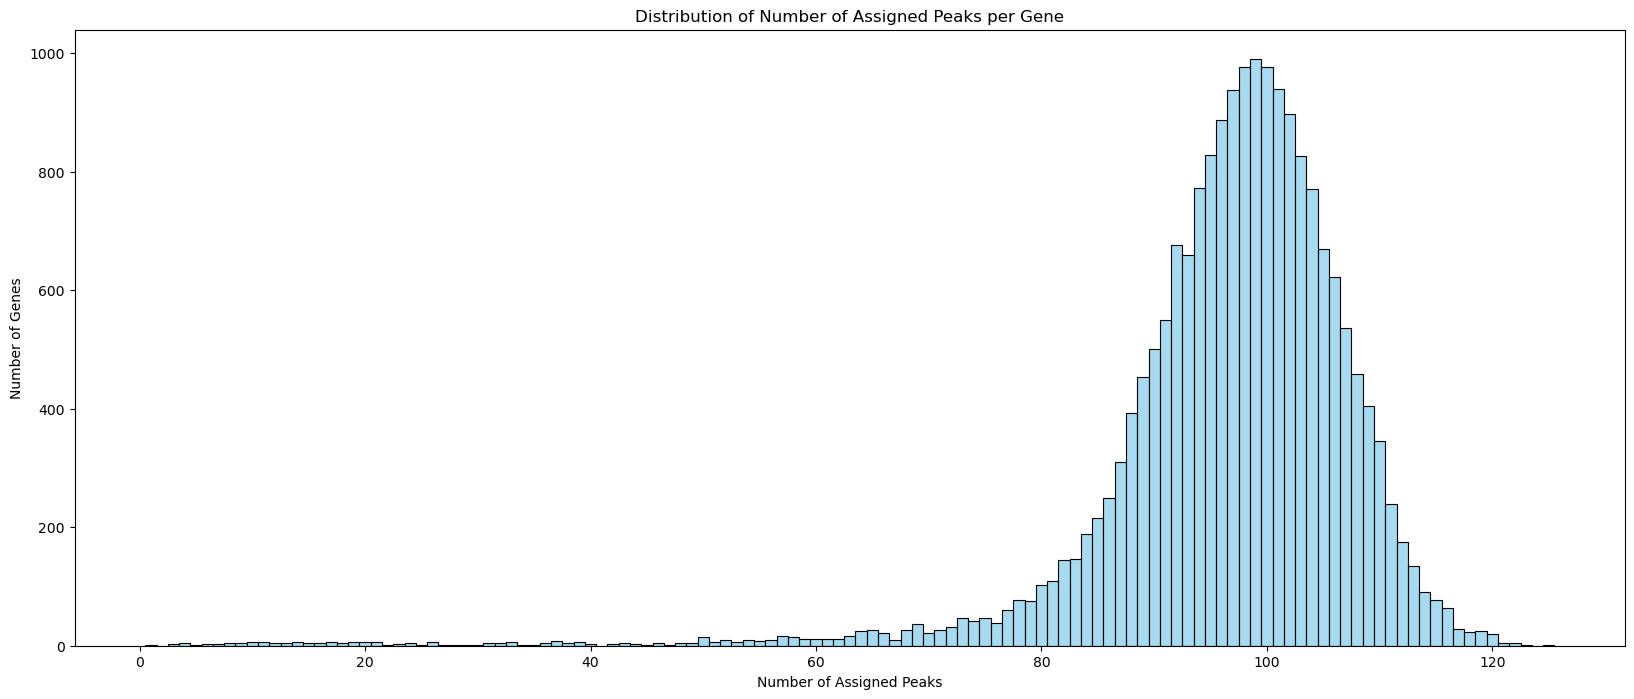

In [5]:
#plot the num_assigned_peaks column as a histogram
import matplotlib.pyplot as plt
import seaborn as sns

#make bin sizes equally spaced
plt.figure(figsize=(20, 8))
sns.histplot(peak_counts["num_assigned_peaks"], bins=range(0, peak_counts["num_assigned_peaks"].max() + 1), edgecolor="black", color="skyblue", binwidth=1, discrete=True)

#make bin sizes equally spaced
plt.xlabel("Number of Assigned Peaks")
plt.ylabel("Number of Genes")
plt.title("Distribution of Number of Assigned Peaks per Gene")
#plt.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/num_assigned_peaks_histogram_100kb.png")
plt.show()

In [6]:
#create a new column in the original dataframe that counts the number of assigned peaks for each gene
window_assignment["num_assigned_peaks"] = window_assignment["assigned_peaks"].apply(len)
window_assignment.head()

,gene_id,assigned_peaks,num_assigned_peaks
0,a1cf,"[['12-6186644-6187111', '12-6190483-6191143',...",95
1,a2ml,"[['15-21143884-21144162', '15-21033797-210340...",77
2,aaas,"[['9-323370-323691', '9-209853-211311', '9-2...",110
3,aacs,"[['5-18949828-18950713', '5-18811696-18812645...",88
4,aadac,"[['15-1052335-1053001', '15-1029184-1030074',...",100


In [7]:
#create a dataframe that includes gene_id, assigned_peaks, and peak_window columns
import numpy as np
max_peaks = window_assignment["num_assigned_peaks"].max()
bin_edges = np.arange(0, max_peaks + 10, 10)  # 0, 10, 20, ..., covering max_peaks

labels = ["0"] + [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(len(bin_edges) - 1)]

window_assignment["peak_count_window"] = pd.cut(
    window_assignment["num_assigned_peaks"],
    bins=[-1] + list(bin_edges),  # -1 so that 0 falls into its own bin
    right=True,
    labels=labels
)

In [8]:
window_assignment.head

,gene_id,assigned_peaks,num_assigned_peaks,peak_count_window
0,a1cf,"[['12-6186644-6187111', '12-6190483-6191143',...",95,90-100
1,a2ml,"[['15-21143884-21144162', '15-21033797-210340...",77,70-80
2,aaas,"[['9-323370-323691', '9-209853-211311', '9-2...",110,100-110
3,aacs,"[['5-18949828-18950713', '5-18811696-18812645...",88,80-90
4,aadac,"[['15-1052335-1053001', '15-1029184-1030074',...",100,90-100


In [ ]:
#save window_assignment to a new csv file
window_assignment.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/window_assignment_with_peak_counts_100kb.csv", index=False)

# Load OLS and COR results to add the peak_count_window

In [1]:
#load the window_assignment_with_peak_counts_100kb.csv file to check if the new columns are there
import pandas as pd
window_assignment = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/window_assignment_with_peak_counts_100kb.csv")
window_assignment.head()

#load the ols and correlation results dataframes
ols_all_df_combined = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_range_df_ct_time.csv")
cor_100kb_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_100kb_results.csv")

In [2]:
ols_100kb_df = ols_all_df_combined[ols_all_df_combined["window"] == "100kb"]
ols_100kb_df.head()

,window,gene,peak,coef,pval,category
8373129,100kb,a1cf,12-6186644-6187111,0.136268,0.029053,sig. positive
8373130,100kb,a1cf,12-6190483-6191143,0.117251,0.071505,non-significant
8373131,100kb,a1cf,12-6225169-6226018,0.021632,0.686530,non-significant
8373132,100kb,a1cf,12-6114452-6114950,-0.004327,0.945030,non-significant
8373133,100kb,a1cf,12-6140521-6140735,-0.036762,0.493567,non-significant


In [3]:
# classify every peak–gene pair into one of three categories to cor results

def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_100kb_df["category"] = cor_100kb_df.apply(classify_pair, axis=1)
cor_100kb_df.head()

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj,category
0,100kb,a1cf,12-6186644-6187111,0.193512,0.006576,2.182015,0.034600,1.460927,sig. positive
1,100kb,a1cf,12-6190483-6191143,0.135734,0.057840,1.237772,0.173677,0.760259,non-significant
2,100kb,a1cf,12-6225169-6226018,0.080739,0.260606,0.584015,0.472269,0.325810,non-significant
3,100kb,a1cf,12-6114452-6114950,0.125358,0.079997,1.096924,0.217494,0.662553,non-significant
4,100kb,a1cf,12-6140521-6140735,0.040975,0.568525,0.245251,0.748452,0.125836,non-significant


In [4]:
#add the window_assignment information to the cor_100kb_df dataframe by merging on gene_id
#rename window_assignment gene_id column to gene to match the cor_100kb_df dataframe
window_assignment = window_assignment.rename(columns={"gene_id": "gene"})
#merge on gene_id and assign the peak_count_window to the cor_100kb_df dataframe
cor_100kb_df = cor_100kb_df.merge(window_assignment[["gene", "peak_count_window"]], on="gene", how="left")
print(cor_100kb_df.head())

  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.193512  0.006576         2.182015   
1  100kb  a1cf  12-6190483-6191143     0.135734  0.057840         1.237772   
2  100kb  a1cf  12-6225169-6226018     0.080739  0.260606         0.584015   
3  100kb  a1cf  12-6114452-6114950     0.125358  0.079997         1.096924   
4  100kb  a1cf  12-6140521-6140735     0.040975  0.568525         0.245251   

       padj  neglog10_padj         category peak_count_window  
0  0.034600       1.460927    sig. positive            90-100  
1  0.173677       0.760259  non-significant            90-100  
2  0.472269       0.325810  non-significant            90-100  
3  0.217494       0.662553  non-significant            90-100  
4  0.748452       0.125836  non-significant            90-100  


In [5]:
#add the window_assignment information to the ols_100kb_df dataframe by merging on gene
ols_100kb_df = ols_100kb_df.merge(window_assignment[["gene", "peak_count_window"]], on="gene", how="left")
print(ols_100kb_df.head())

  window  gene                peak      coef      pval         category  \
0  100kb  a1cf  12-6186644-6187111  0.136268  0.029053    sig. positive   
1  100kb  a1cf  12-6190483-6191143  0.117251  0.071505  non-significant   
2  100kb  a1cf  12-6225169-6226018  0.021632  0.686530  non-significant   
3  100kb  a1cf  12-6114452-6114950 -0.004327  0.945030  non-significant   
4  100kb  a1cf  12-6140521-6140735 -0.036762  0.493567  non-significant   

  peak_count_window  
0            90-100  
1            90-100  
2            90-100  
3            90-100  
4            90-100  


In [6]:
#sort the dataframe by the peak_count_window column ascending
ols_100kb_df = ols_100kb_df.sort_values("peak_count_window")
cor_100kb_df = cor_100kb_df.sort_values("peak_count_window")
cor_100kb_df.head()

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj,category,peak_count_window
1847696,100kb,znf973,4-37245946-37246145,0.026740,0.709874,0.148819,0.843935,0.073691,non-significant,0-10
1312509,100kb,si:ch211-197e7.1,4-49765707-49765916,0.106321,0.138027,0.860036,0.314028,0.503031,non-significant,0-10
1815066,100kb,zgc:174275,4-56321109-56322048,0.034968,0.626560,0.203037,0.789686,0.102546,non-significant,0-10
1406351,100kb,si:dkey-40j3.3,4-57469379-57469775,-0.067217,0.349233,0.456884,0.564805,0.248101,non-significant,0-10
1406352,100kb,si:dkey-40j3.3,4-57510976-57512309,-0.139140,0.051779,1.285846,0.160607,0.794235,non-significant,0-10


In [7]:
window_labels = [window_assignment["peak_count_window"].sort_values().unique()]
window_labels

[array(['0-10', '10-20', '100-110', '110-120', '120-130', '20-30', '30-40',
        '40-50', '50-60', '60-70', '70-80', '80-90', '90-100'],
       dtype=object)]

In [8]:
#create a dictionary with the significant peaks for each gene for each peak_count_window, by filtering the results for significant peaks and grouping by gene and peak_count_window, and saving the significant peaks in a list for each gene and peak_count_window
window_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100', '100-110', '110-120', '120-130']

sig_ols_df = ols_100kb_df[ols_100kb_df["category"].isin(["sig. negative", "sig. positive"])] 

sig_peaks_by_gene_ols = {} 

for window in window_labels:
    sig_peaks_by_gene_ols[window] = {}
    window_df = sig_ols_df[sig_ols_df["peak_count_window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_ols[window][gene_id] = group["peak"].tolist()

In [9]:
print(next(iter(sig_peaks_by_gene_ols.items())))

('0-10', {'si:ch211-197e7.1': ['4-49765707-49765916'], 'si:ch211-207e19.2': ['4-56110786-56111229', '4-56090517-56091419'], 'si:ch211-238e22.4': ['4-57091129-57091336'], 'si:dkey-237m9.1': ['4-41922674-41922896'], 'si:dkey-51d8.1': ['4-44961590-44961895'], 'zgc:174275': ['4-56265553-56265789']})


In [10]:
#create a dictionary with the significant peaks for each gene for each peak_count_window, by filtering the results for significant peaks and grouping by gene and peak_count_window, and saving the significant peaks in a list for each gene and peak_count_window
sig_cor_df = cor_100kb_df[cor_100kb_df["category"].isin(["sig. negative", "sig. positive"])]
sig_peaks_by_gene_cor = {}
for window in window_labels:
    sig_peaks_by_gene_cor[window] = {}
    window_df = sig_cor_df[sig_cor_df["peak_count_window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_cor[window][gene_id] = group["peak"].tolist()

print(next(iter(sig_peaks_by_gene_cor.items())))

('0-10', {'si:ch211-141e20.2': ['9-19696386-19696788', '9-19813955-19814167'], 'si:ch211-207e19.2': ['4-56090517-56091419'], 'si:ch211-237a4.2': ['4-56495735-56496139'], 'si:dkey-193i10.4': ['4-71177637-71177844'], 'si:dkey-57k17.1': ['4-58079155-58079357', '4-58076020-58076594', '4-58066540-58067258'], 'si:dkey-71l4.4': ['4-75511479-75511776'], 'si:dkeyp-80d11.4': ['4-70942817-70943062'], 'zgc:174275': ['4-56326906-56327745', '4-56323357-56324154'], 'zgc:174650': ['4-40981021-40981255'], 'znf1072': ['4-42999864-43000249', '4-43142059-43142361'], 'znf973': ['4-37320494-37320726']})


In [11]:
#define functions to calculate jaccard similarity and retention between two sets of peaks

def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    intersection = len(a & b)
    union = len(a | b)
    return intersection / union if union > 0 else 0

def retention(set_small, set_large):
    a, b = set(set_small), set(set_large)
    return len(a & b) / len(a) if len(a) > 0 else 0

In [32]:
#number of genes in both datasets
genes_in_ols = set(ols_100kb_df["gene"].unique())
genes_in_cor = set(cor_100kb_df["gene"].unique())
genes_in_both = genes_in_ols & genes_in_cor
print(f"Number of genes in OLS dataset: {len(genes_in_ols)}")
print(f"Number of genes in Correlation dataset: {len(genes_in_cor)}")
print(f"Number of genes in both datasets: {len(genes_in_both)}")

Number of genes in OLS dataset: 19166
Number of genes in Correlation dataset: 19166
Number of genes in both datasets: 19166


In [33]:
#number of gene in significant peaks in both datasets
sig_genes_in_ols = set(sig_ols_df["gene"].unique())
sig_genes_in_cor = set(sig_cor_df["gene"].unique())
sig_genes_in_both = sig_genes_in_ols & sig_genes_in_cor
print(f"Number of genes in significant OLS peaks: {len(sig_genes_in_ols)}")
print(f"Number of genes in significant Correlation peaks: {len(sig_genes_in_cor)}")
print(f"Number of genes in significant peaks in both datasets: {len(sig_genes_in_both)}")

Number of genes in significant OLS peaks: 18486
Number of genes in significant Correlation peaks: 18424
Number of genes in significant peaks in both datasets: 17827


In [ ]:
#compute the jaccard similarity and retention for each gene and each pair of windows, and store the results in a long format dataframe and a matrix format dataframe for both jaccard and retention

all_genes = set(ols_100kb_df["gene"].unique()) #take the union of the genes from both dataframes to make sure we include all genes that have significant peaks in either dataset

window_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100', '100-110', '110-120', '120-130']

def build_long_and_matrix(score_fn, dict1, dict2, window_labels, all_genes, value_name):
    records = []
    for w1 in window_labels:
        for w2 in window_labels:
            for gene in all_genes:
                peaks1 = dict1[w1].get(gene, [])
                peaks2 = dict2[w2].get(gene, [])
                if len(peaks1) > 0 and len(peaks2) > 0:
                    records.append({
                        "w1": w1,
                        "w2": w2,
                        "gene": gene,
                        value_name: score_fn(peaks1, peaks2)
                    })

    long_df = pd.DataFrame(records)
    matrix = long_df.pivot_table(
        index="w1", columns="w2", values=value_name, aggfunc="mean"
    ).reindex(index=window_labels, columns=window_labels)

    return long_df, matrix


# --- Jaccard ---
jaccard_long, jaccard_matrix = build_long_and_matrix(
    jaccard, sig_peaks_by_gene_ols, sig_peaks_by_gene_cor,
    window_labels, all_genes, value_name="jaccard"
)

# --- Retention (ols -> cor) ---
retention_long_oc, retention_matrix_oc = build_long_and_matrix(
    retention, sig_peaks_by_gene_ols, sig_peaks_by_gene_cor,
    window_labels, all_genes, value_name="retention"
)

# --- Retention (cor -> ols) ---
retention_long_co, retention_matrix_co = build_long_and_matrix(
    retention, sig_peaks_by_gene_cor, sig_peaks_by_gene_ols,
    window_labels, all_genes, value_name="retention"
)

In [20]:
#defining a function to create annotation strings for the heatmap, including the mean value and the number of genes that contributed to that mean value for each cell in the matrix
def make_annot(matrix, counts):
    annot = matrix.copy().astype(object)
    for w1 in matrix.index:
        for w2 in matrix.columns:
            val = matrix.loc[w1, w2]
            n = counts.loc[w1, w2]
            if pd.isna(val):
                annot.loc[w1, w2] = ""
            else:
                n_int = int(n) if not pd.isna(n) else 0
                annot.loc[w1, w2] = f"{val:.2f}\n(n={n_int})"
    return annot

window_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100', '100-110', '110-120', '120-130']

# --- counts for each comparison ---
jaccard_counts = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

retention_counts_oc = retention_long_oc.pivot_table(
    index="w1", columns="w2", values="retention", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

retention_counts_co = retention_long_co.pivot_table(
    index="w1", columns="w2", values="retention", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)


# --- annotation strings ---
jaccard_annot = make_annot(jaccard_matrix, jaccard_counts)
retention_annot_oc = make_annot(retention_matrix_oc, retention_counts_oc)
retention_annot_co = make_annot(retention_matrix_co, retention_counts_co)


# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

#make annotation size smaller
sns.heatmap(jaccard_matrix.astype(float), fmt="", cmap="viridis", ax=axes[0]) #make annotation size smaller
axes[0].set_xlabel("Number of initially assigned peaks")
axes[0].set_ylabel("Number of initially assigned peaks")
axes[0].set_title("Mean Jaccard similarity of ols and cor peaks\nacross initial peak assignments (± 100 kb)", fontsize=9)

sns.heatmap(retention_matrix_oc.astype(float), annot=retention_annot_oc.values, annot_kws={"size": 7}, fmt="", cmap="viridis", ax=axes[1])
axes[1].set_xlabel("Number of initially assigned peaks (correlation)")
axes[1].set_ylabel("Number of initially assigned peaks (ols)")
axes[1].set_title("Mean retention of ols peaks in correlation peaks\nacross window sizes (± 100 kb)", fontsize=9)

sns.heatmap(retention_matrix_co.astype(float), annot_kws={"size": 7}, fmt="", cmap="viridis", ax=axes[2])
axes[2].set_xlabel("Number of initially assigned peaks (ols)")
axes[2].set_ylabel("Number of initially assigned peaks (correlation)")
axes[2].set_title("Mean retention of correlation peaks in ols peaks\nacross window sizes (± 100 kb)", fontsize=9)

plt.tight_layout()

NameError: name 'jaccard_matrix' is not defined

In [34]:
#how to make counts matrix from long format df
counts_matrix = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

#how to make mean matrix from long format df
mean_matrix = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="mean"
).reindex(index=window_labels, columns=window_labels)

In [ ]:
#save the results of long format dataframes 
jaccard_long.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/jaccard_long_100kb.csv", index=False)
retention_long_oc.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/retention_long_oc_100kb.csv", index=False)
retention_long_co.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/retention_long_co_100kb.csv", index=False)


In [19]:
#load the dataframes back in to check if they are saved correctly
import pandas as pd
jaccard_long = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/jaccard_long_100kb.csv")
retention_long_oc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/retention_long_oc_100kb.csv")
retention_long_co = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/ct_time/retention_long_co_100kb.csv")

In [3]:
jaccard_long.head()
retention_long_oc.head()
retention_long_co.head()

,w1,w2,gene,retention
0,0-10,0-10,si:ch211-207e19.2,1.0
1,0-10,0-10,zgc:174275,0.0
2,10-20,10-20,zgc:173720,0.0
3,10-20,10-20,si:ch211-162i8.2,0.0
4,10-20,10-20,zgc:171310,0.1


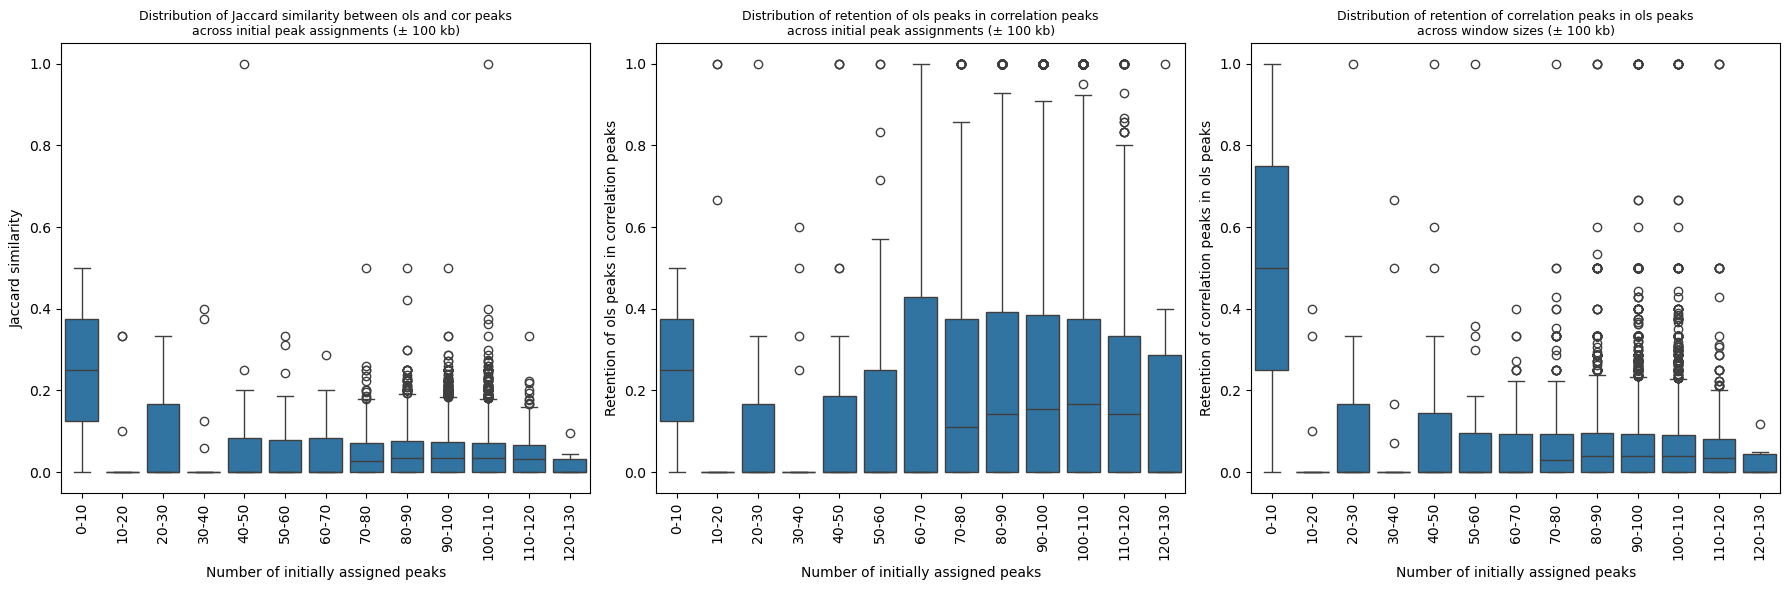

In [21]:
#plot boxplots of the jaccard similarity and retention values for each pair of window sizes, using the long format dataframes
import matplotlib.pyplot as plt
import seaborn as sns   


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x="w1", y="jaccard", data=jaccard_long, ax=axes[0])
axes[0].tick_params(axis='x', rotation=90)
#negative log scale the y-axis of the jaccard similarity plot to better visualize the distribution of values, since many values are close to 0
#axes[0].set_yscale('log')
axes[0].set_xlabel("Number of initially assigned peaks")
axes[0].set_ylabel("Jaccard similarity")
axes[0].set_title("Distribution of Jaccard similarity between ols and cor peaks\nacross initial peak assignments (± 100 kb)", fontsize=9)

sns.boxplot(x="w1", y="retention", data=retention_long_oc, ax=axes[1])
axes[1].tick_params(axis='x', rotation=90)
#axes[1].set_yscale('log')
axes[1].set_xlabel("Number of initially assigned peaks") 
axes[1].set_ylabel("Retention of ols peaks in correlation peaks")
axes[1].set_title("Distribution of retention of ols peaks in correlation peaks\nacross initial peak assignments (± 100 kb)", fontsize=9)

sns.boxplot(x="w1", y="retention", data=retention_long_co, ax=axes[2])
axes[2].tick_params(axis='x', rotation=90)
#axes[2].set_yscale('log')
axes[2].set_xlabel("Number of initially assigned peaks") 
axes[2].set_ylabel("Retention of correlation peaks in ols peaks")
axes[2].set_title("Distribution of retention of correlation peaks in ols peaks\nacross window sizes (± 100 kb)", fontsize=9)

plt.tight_layout()

In [15]:
#add a category column, by classifying the retention similarity values into three categories: "low" for values < 0.25, "moderate" for values between 0.25 and 0.50, and "high" for values between 0.75 and very high for values > 0.75
def classify_retention(value):
    if value < 0.25:
        return "low"
    elif 0.25 <= value < 0.50:
        return "moderate"
    elif 0.50 <= value < 0.75:
        return "high"
    else:
        return "very high"

retention_long_oc["category"] = retention_long_oc["retention"].apply(classify_retention)
retention_long_co["category"] = retention_long_co["retention"].apply(classify_retention)
print(retention_long_oc.head())
retention_long_co.head()    

      w1     w2               gene  retention   category
0   0-10   0-10  si:ch211-207e19.2        0.5       high
1   0-10   0-10         zgc:174275        0.0        low
2  10-20  10-20         zgc:173720        0.0        low
3  10-20  10-20   si:ch211-162i8.2        0.0        low
4  10-20  10-20         zgc:171310        1.0  very high


,w1,w2,gene,retention,category
0,0-10,0-10,si:ch211-207e19.2,1.0,very high
1,0-10,0-10,zgc:174275,0.0,low
2,10-20,10-20,zgc:173720,0.0,low
3,10-20,10-20,si:ch211-162i8.2,0.0,low
4,10-20,10-20,zgc:171310,0.1,low


In [16]:
#rename the column w1 to ols_peak_count_window and w2 to cor_peak_count_window in both retention_long_oc and retention_long_co dataframes
retention_long_oc = retention_long_oc.rename(columns={"w1": "ols_peak_count_window", "w2": "cor_peak_count_window"})
retention_long_co = retention_long_co.rename(columns={"w1": "cor_peak_count_window", "w2": "ols_peak_count_window"})
print(retention_long_oc.head())
print(retention_long_co.head())

  ols_peak_count_window cor_peak_count_window               gene  retention  \
0                  0-10                  0-10  si:ch211-207e19.2        0.5   
1                  0-10                  0-10         zgc:174275        0.0   
2                 10-20                 10-20         zgc:173720        0.0   
3                 10-20                 10-20   si:ch211-162i8.2        0.0   
4                 10-20                 10-20         zgc:171310        1.0   

    category  
0       high  
1        low  
2        low  
3        low  
4  very high  
  cor_peak_count_window ols_peak_count_window               gene  retention  \
0                  0-10                  0-10  si:ch211-207e19.2        1.0   
1                  0-10                  0-10         zgc:174275        0.0   
2                 10-20                 10-20         zgc:173720        0.0   
3                 10-20                 10-20   si:ch211-162i8.2        0.0   
4                 10-20                 

In [ ]:
#aggregate the number of significant peaks per gene and category  
agg_ols_all_df_pos = (
    ols_all_df_pos
    .dropna(subset=["gene", "retention", "category"]) #
    .groupby(["ols_peak_count_window", "category"]) 
    .size()
    .reset_index(name="count")
)

agg_ols_all_df_neg = (
    ols_all_df_neg
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["ols_peak_count_window", "category"])
    .size()
    .reset_index(name="count")

In [ ]:
#merge the aggregated dataframes for positive and negative windows to compare the number of significant peaks per gene and category across windows
agg_ols_all_df_combined = pd.concat(
    [agg_ols_all_df_neg.assign(direction="neg"),
     agg_ols_all_df_pos.assign(direction="pos")],
    ignore_index=True
)
agg_ols_all_df_combined.head()

In [ ]:
#counting the number of significant peaks per gene and category across windows for both positive and negative windows
significant_peaks_count = agg_ols_all_df_combined.groupby(["window","category", "direction", "count"]).size().reset_index(name="total_genes")
significant_peaks_count.head()

In [ ]:
#calculate the fraction of total_genes within one category and window by dividing the total_genes by the total number of unique genes in that window and category across both directions
significant_peaks_count["fraction"] = (
    significant_peaks_count["total_genes"]
    / significant_peaks_count.groupby(
        ["window", "window_order", "category"]
    )["total_genes"].transform("sum")
)

significant_peaks_count.head()

In [ ]:
#Add window_label column for 5kb window it should be labled TSS+5kb, for 10kb it should be TSS+10kb and so on for all windows if the direction is pos, if direction is neg, it should be labeled TSS-5kb for 5kb window, TSS+10kb for 10kb window and so on for all windows
significant_peaks_count["window_label"] = significant_peaks_count.apply(
    lambda row: f"TSS+{row['window']}" if row["direction"] == "pos" else f"TSS-{row['window']}",
    axis=1
)
significant_peaks_count.head()

In [ ]:
#sort the dataframe by the window_order column to ensure the windows are in the correct order for visualization
significant_peaks_count = significant_peaks_count.sort_values("window_order")
significant_peaks_count.head()

In [ ]:
#sanity check: confirm that the fraction column sums to 1 for each window and category across both directions
fraction_sums = significant_peaks_count.groupby(["window_order", "category"])["fraction"].sum().reset_index()
print(fraction_sums[fraction_sums["fraction"] != 1.0])

In [ ]:
#visualize the fraction of genes with significant peaks by window and category using a stacked bar plot, where the x-axis represents the windows, the y-axis represents the fraction of genes, and the bars are colored by category. The color intensity of the bars will represent the count of significant peaks per gene, with a color gradient from light to dark blue indicating low to high counts. Additionally, we will use different hatching patterns to distinguish between categories, and include a legend to indicate which pattern corresponds to which category.
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch

# use raw df — no aggregation, keep individual count rows
plot_df = significant_peaks_count.copy()

windows = plot_df['window_label'].unique()  # e.g. ['5kb', '10kb', '20kb', '50kb', '100kb']
categories = sorted(plot_df['category'].unique())
n_cats = len(categories)
n_windows = len(windows)

count_min = plot_df['count'].min()
count_max = plot_df['count'].max()
norm = mcolors.Normalize(vmin=count_min, vmax=count_max)
cmap = cm.Spectral  

bar_width = 0.15
#x_positions should be in the order of the window_order column, which is already sorted in the significant_peaks_count dataframe
x_positions = sorted(plot_df['window_order'].unique())

offsets = np.linspace(-(n_cats - 1) / 2, (n_cats - 1) / 2, n_cats) * (bar_width + 0.02)
hatches = ['', '///', '...']
fig, ax = plt.subplots(figsize=(12, 6))
for i, category in enumerate(categories):
    cat_data = plot_df[plot_df['category'] == category]

    for j, window in enumerate(windows):
        win_cat_data = cat_data[cat_data['window_label'] == window]

        if win_cat_data.empty:
            continue

        #enforce LOW → HIGH stacking order
        win_cat_data = win_cat_data.sort_values('count', ascending=True)

        x_pos = x_positions[j] + offsets[i]

        total = win_cat_data['fraction'].sum()
        bottom = 0

        for _, row in win_cat_data.iterrows():
            frac = row['fraction'] / total

            ax.bar(
                x_pos,
                frac,
                width=bar_width,
                bottom=bottom,
                color=cmap(norm(row['count'])),  # consistent with colormap
                edgecolor='black',
                hatch=hatches[i],
                label=category if (j == 0 and bottom == 0) else ""
            )

            bottom += frac
#labeling the colorbar with the count values
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.08, label='Number of Peaks per gene')  # Add label to colorbar
cbar.set_ticks(np.arange(count_min, count_max, 3))
cbar.ax.tick_params(labelsize=6)  # Set ticks at integer values with a step of 2, adjust as needed
# Get colorbar position in figure coordinates
cbar_pos = cbar.ax.get_position()

ax.set_xticks(x_positions)
ax.set_xticklabels(windows, rotation=90)
ax.set_xlabel('Window')
ax.set_ylabel('Fraction of Genes')
ax.set_title('Fraction of Genes with peaks by Window and Category')
handles = [Patch(facecolor='white', edgecolor='black', hatch=hatches[i], label=categories[i]) for i in range(n_cats)]
ax.legend(handles=handles, title='Category', loc ='lower left', bbox_to_anchor=(cbar_pos.x0, cbar_pos.y1 +0.06), bbox_transform=fig.transFigure) #positioning the legend outside the plot area to avoid overlapping with the bars
plt.tight_layout()
plt.show()